In [1]:
import numpy as np
from scipy.integrate import solve_ivp
import matplotlib.pyplot as plt

In [2]:
##initial values
P = 100000 # total population
V0 =0 # vaccinated
I0 = 1 # infected
beta =0.3
gamma =0.2
days =200


S0 = P-V0 - I0 
R0 = V0
y0 = [S0,I0,R0]

def SIR_model(t, y):
    S, I, R = y
    dS = -beta * S * I / P
    dI =  beta * S * I / P - gamma * I
    dR =  gamma * I
    return [dS, dI, dR]

t_span = (0, days)
t_eval = np.linspace(0, days, 200)

sol = solve_ivp(SIR_model, t_span, y0, t_eval=t_eval, method='RK45')
S, I, R = sol.y

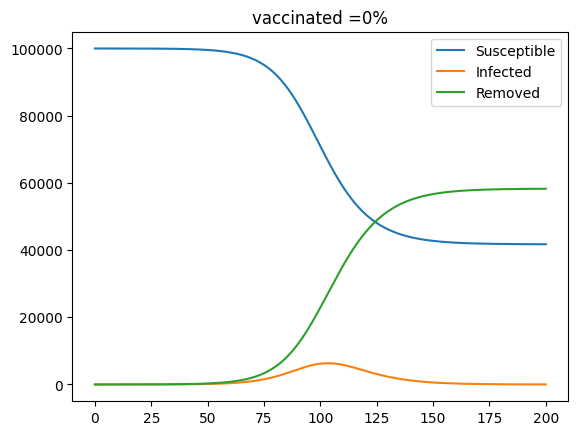

In [3]:
plt.plot(t_eval,S,label='Susceptible')
plt.plot(t_eval,I,label='Infected')
plt.plot(t_eval,R,label='Removed')
plt.title('vaccinated =0%')
plt.legend()
plt.show()

In [4]:
P = 100000 # total population
V0 =0 # vaccinated
I0 = 1 # infected
beta =0.3
gamma =0.2
days =200

def Gillespie_model(N,I0,beta,gamma, days):

    S=N-I0
    I =I0
    R=0
    t=0

    t_=[]
    s_=[]
    i_=[]
    r_=[]
    
    while t< days and I>0:
        rate_infection = beta * S * I / P
        rate_recovery = gamma * I
        total_rate = rate_infection + rate_recovery
        dt = np.random.exponential(1 / total_rate) # events have exponential distribution
        t = t+dt
        
        infection_prob = rate_infection/total_rate
        

        if total_rate ==0:
            break

        if np.random.random() < infection_prob:
            #infection
            S =S-1  
            I =I+1
        #recovery
        else:
            I =I-1
            R =R+1
        t_.append(t)
        s_.append(S)
        i_.append(I)
        r_.append(R)

    return t_,s_,i_,r_
        



        




In [5]:
a,b,c,d =Gillespie_model(100000,1,0.3,0.2, 200)


[0.6498339165326765,
 2.6079307890135492,
 2.81541078867366,
 3.1546769580889635,
 3.3343954261178634,
 3.340236737155238,
 3.36618792416492,
 3.62547735127737,
 3.669519794265225,
 3.679626749969014,
 4.0265035123968795,
 4.0773722155794845,
 4.730927888873392,
 4.857109526951404,
 5.167026881032526,
 5.210591345154187,
 5.951645862334422,
 6.0543851113052,
 6.204518841859249,
 6.332732311616386,
 6.7340962773710995,
 6.83308549367441,
 7.666443314368748,
 7.717523689515712,
 7.876116874213056,
 8.016825662324427,
 8.645407844941268,
 8.961957039215172,
 9.221189671061653,
 9.867173501487814,
 10.574426112233091,
 10.705861177196235,
 10.99744761207294,
 11.17042251627015,
 11.183641476958014,
 11.260893588212586,
 11.294868734375397,
 11.818973351988346,
 12.187207395040375,
 12.374449744186169,
 12.561252027789374,
 12.720201777158849,
 13.469867100960235,
 13.486405879215134,
 13.685793590519708,
 13.766250131738301,
 14.003259743871084,
 14.313982162967378,
 14.499956871631204,
 1

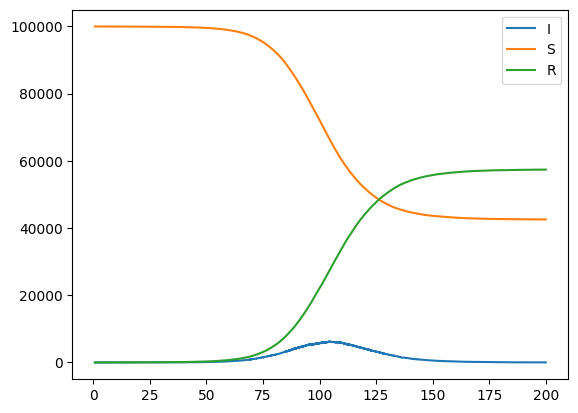

In [21]:
plt.plot(a,c,label='I')
plt.plot(a,b,label='S')
plt.plot(a,d,label='R')
plt.legend()
plt.show()

In [6]:
len(a)

114833